In [23]:
from google.colab import drive
drive.mount('/content/drive')

import os
path = '/content/drive/MyDrive/house pricing'   # adjust if your folder name differs
print(os.listdir(path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['sample_submission.csv', 'data_description.txt', 'test.csv', 'train.csv']


In [24]:
!pip install optuna xgboost lightgbm catboost -q


In [4]:
import numpy as np
import pandas as pd
from scipy.stats import skew
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold, RepeatedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso, Ridge, ElasticNet, LassoCV
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
print("imports ok")

imports ok


In [5]:
train = pd.read_csv(f'{path}/train.csv')
test  = pd.read_csv(f'{path}/test.csv')

# Two documented bad sales: huge living area, very low price. Remove from TRAIN only.
train = train.drop(train[(train['GrLivArea'] > 4000) &
                         (train['SalePrice'] < 300000)].index).reset_index(drop=True)

train_ID, test_ID = train['Id'], test['Id']
ntrain = train.shape[0]
y = np.log1p(train['SalePrice'])   # log-transform target (matches competition metric)

all_data = pd.concat([train.drop(['Id','SalePrice'], axis=1),
                      test.drop(['Id'], axis=1)]).reset_index(drop=True)
print('combined:', all_data.shape)   # expect (2917, 79)

combined: (2917, 79)


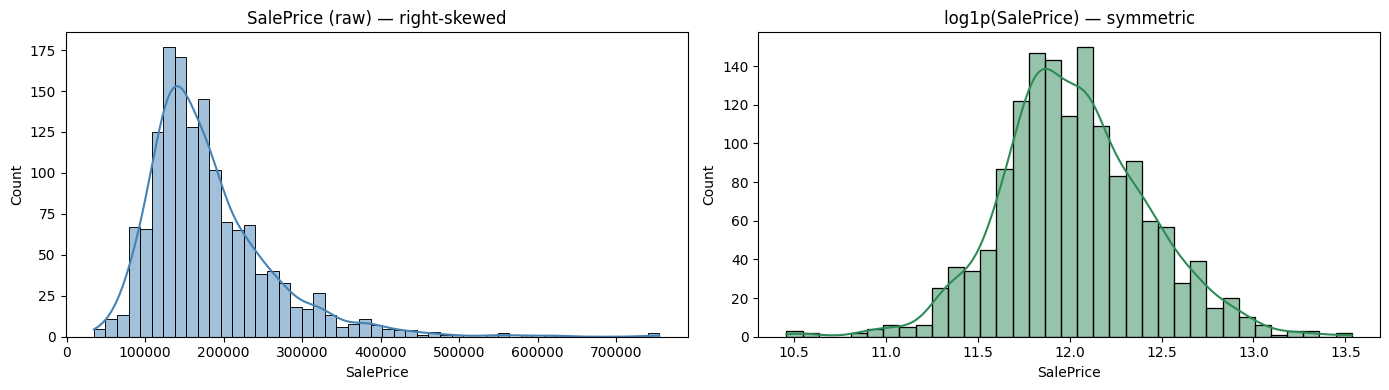

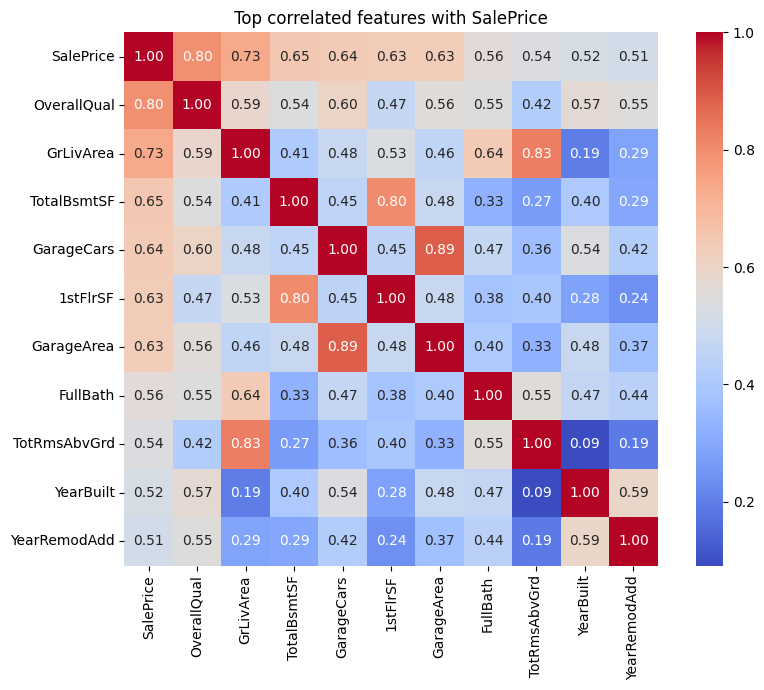

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(train['SalePrice'], kde=True, ax=ax[0], color='steelblue')
ax[0].set_title('SalePrice (raw) — right-skewed')
sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=ax[1], color='seagreen')
ax[1].set_title('log1p(SalePrice) — symmetric')
plt.tight_layout(); plt.show()

# top 10 features most correlated with price
num = train.select_dtypes(include=[np.number])
top = num.corr()['SalePrice'].abs().sort_values(ascending=False).head(11).index
plt.figure(figsize=(9, 7))
sns.heatmap(train[top].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Top correlated features with SalePrice'); plt.tight_layout(); plt.show()

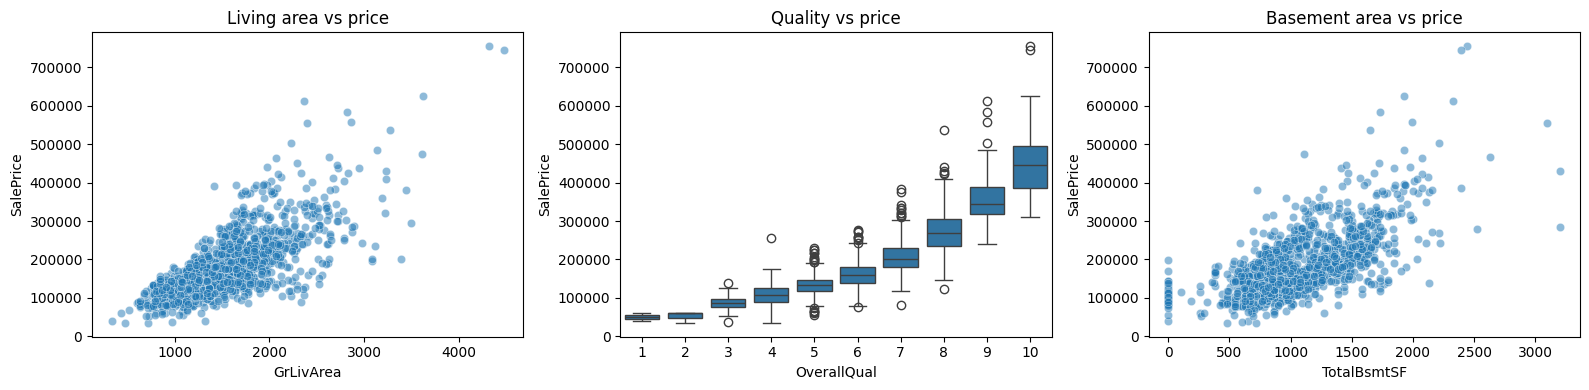

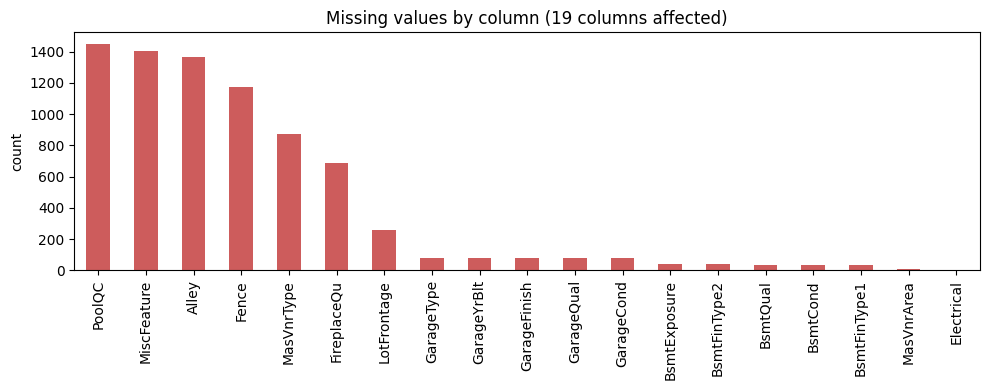

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train, ax=ax[0], alpha=0.5)
ax[0].set_title('Living area vs price')
sns.boxplot(x='OverallQual', y='SalePrice', data=train, ax=ax[1])
ax[1].set_title('Quality vs price')
sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=train, ax=ax[2], alpha=0.5)
ax[2].set_title('Basement area vs price')
plt.tight_layout(); plt.show()

# missing-value overview (on raw train before cleaning)
miss = train.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
plt.figure(figsize=(10, 4))
miss.plot(kind='bar', color='indianred')
plt.title(f'Missing values by column ({len(miss)} columns affected)')
plt.ylabel('count'); plt.tight_layout(); plt.show()

In [6]:
none_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
             'GarageType','GarageFinish','GarageQual','GarageCond',
             'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','MasVnrType']
for c in none_cols:
    all_data[c] = all_data[c].fillna('None')

zero_cols = ['GarageYrBlt','GarageArea','GarageCars','BsmtFinSF1','BsmtFinSF2',
             'BsmtUnfSF','TotalBsmtSF','BsmtFullBath','BsmtHalfBath','MasVnrArea']
for c in zero_cols:
    all_data[c] = all_data[c].fillna(0)

all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

for c in ['MSZoning','Electrical','KitchenQual','Exterior1st','Exterior2nd','SaleType']:
    all_data[c] = all_data[c].fillna(all_data[c].mode()[0])

all_data['Functional'] = all_data['Functional'].fillna('Typ')
all_data = all_data.drop(['Utilities'], axis=1)

print('nulls remaining:', all_data.isnull().sum().sum())   # expect 0

nulls remaining: 0


In [7]:
qual_map = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'None':0}
for c in ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
          'KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']:
    all_data[c] = all_data[c].map(qual_map)

all_data['BsmtExposure'] = all_data['BsmtExposure'].map({'Gd':4,'Av':3,'Mn':2,'No':1,'None':0})
fin_map = {'GLQ':6,'ALQ':5,'BLQ':4,'Rec':3,'LwQ':2,'Unf':1,'None':0}
all_data['BsmtFinType1'] = all_data['BsmtFinType1'].map(fin_map)
all_data['BsmtFinType2'] = all_data['BsmtFinType2'].map(fin_map)
all_data['GarageFinish'] = all_data['GarageFinish'].map({'Fin':3,'RFn':2,'Unf':1,'None':0})
all_data['Functional']   = all_data['Functional'].map(
    {'Typ':7,'Min1':6,'Min2':5,'Mod':4,'Maj1':3,'Maj2':2,'Sev':1,'Sal':0})
print('ordinal encoding done')

ordinal encoding done


In [8]:
all_data['TotalSF']      = all_data['TotalBsmtSF']+all_data['1stFlrSF']+all_data['2ndFlrSF']
all_data['TotalBath']    = (all_data['FullBath']+0.5*all_data['HalfBath']
                            +all_data['BsmtFullBath']+0.5*all_data['BsmtHalfBath'])
all_data['TotalPorchSF'] = (all_data['OpenPorchSF']+all_data['EnclosedPorch']
                            +all_data['3SsnPorch']+all_data['ScreenPorch']+all_data['WoodDeckSF'])
all_data['Age']          = all_data['YrSold']-all_data['YearBuilt']
all_data['EffectiveAge'] = all_data['YrSold']-all_data['YearRemodAdd']
all_data['IsRemodeled']  = (all_data['YearRemodAdd']!=all_data['YearBuilt']).astype(int)
all_data['HasPool']      = (all_data['PoolArea']>0).astype(int)
all_data['Has2ndFloor']  = (all_data['2ndFlrSF']>0).astype(int)
all_data['HasGarage']    = (all_data['GarageArea']>0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces']>0).astype(int)
all_data['HasBsmt']      = (all_data['TotalBsmtSF']>0).astype(int)
all_data['Qual_x_TotalSF']   = all_data['OverallQual'] * all_data['TotalSF']
all_data['Qual_x_GrLivArea'] = all_data['OverallQual'] * all_data['GrLivArea']
all_data['OverallQual_2']    = all_data['OverallQual'] ** 2
qsc = ['OverallQual','ExterQual','BsmtQual','KitchenQual','GarageQual','FireplaceQu','HeatingQC']
all_data['TotalQualScore']   = all_data[qsc].sum(axis=1)
all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)
all_data['MoSold']     = all_data['MoSold'].astype(str)
print('feature engineering done')

feature engineering done


In [9]:
numeric_feats = all_data.dtypes[all_data.dtypes != 'object'].index
skewed = all_data[numeric_feats].apply(lambda x: skew(x))
for c in skewed[abs(skewed) > 0.75].index:
    all_data[c] = np.log1p(all_data[c])

all_data = pd.get_dummies(all_data)   # <-- one-hot encoding here
X      = all_data[:ntrain]
X_test = all_data[ntrain:]
print('X:', X.shape, ' X_test:', X_test.shape, ' y:', y.shape)

X: (1458, 275)  X_test: (1459, 275)  y: (1458,)


In [10]:
kf  = KFold(n_splits=5, shuffle=True, random_state=42)
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

def cv_kf(model):      # fast single-KFold — used inside Optuna
    return -cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=kf).mean()

def cv(model):  # repeated KFold — used for final comparisons
    return -cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=rkf).mean()

best = {}   # will hold the tuned models
print("cv helpers ready")

cv helpers ready


In [11]:
sL = optuna.create_study(direction='minimize')
sL.optimize(lambda t: cv_kf(make_pipeline(RobustScaler(),
    Lasso(alpha=t.suggest_float('alpha',1e-4,1e-2,log=True), max_iter=50000))),
    n_trials=30, show_progress_bar=True)
best['lasso'] = make_pipeline(RobustScaler(), Lasso(alpha=sL.best_params['alpha'], max_iter=50000))
print('Lasso  ', round(sL.best_value,4), sL.best_params)

sR = optuna.create_study(direction='minimize')
sR.optimize(lambda t: cv_kf(make_pipeline(RobustScaler(),
    Ridge(alpha=t.suggest_float('alpha',1.0,50.0,log=True)))),
    n_trials=30, show_progress_bar=True)
best['ridge'] = make_pipeline(RobustScaler(), Ridge(alpha=sR.best_params['alpha']))
print('Ridge  ', round(sR.best_value,4), sR.best_params)

sE = optuna.create_study(direction='minimize')
sE.optimize(lambda t: cv_kf(make_pipeline(RobustScaler(),
    ElasticNet(alpha=t.suggest_float('alpha',1e-4,1e-2,log=True),
               l1_ratio=t.suggest_float('l1_ratio',0.1,1.0), max_iter=50000))),
    n_trials=40, show_progress_bar=True)
best['elastic'] = make_pipeline(RobustScaler(), ElasticNet(
    alpha=sE.best_params['alpha'], l1_ratio=sE.best_params['l1_ratio'], max_iter=50000))
print('Elastic', round(sE.best_value,4), sE.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]

Lasso   0.1115 {'alpha': 0.00048329429504179124}


  0%|          | 0/30 [00:00<?, ?it/s]

Ridge   0.1136 {'alpha': 8.204447644459625}


  0%|          | 0/40 [00:00<?, ?it/s]

Elastic 0.1115 {'alpha': 0.0006181722475620843, 'l1_ratio': 0.8071036696848914}


In [12]:
def obj_xgb(t):
    p = {'n_estimators':     t.suggest_int('n_estimators',1000,4000,step=500),
         'learning_rate':    t.suggest_float('learning_rate',0.005,0.05,log=True),
         'max_depth':        t.suggest_int('max_depth',2,4),
         'min_child_weight': t.suggest_int('min_child_weight',1,8),
         'subsample':        t.suggest_float('subsample',0.5,0.9),
         'colsample_bytree': t.suggest_float('colsample_bytree',0.3,0.8),
         'reg_alpha':        t.suggest_float('reg_alpha',1e-3,10,log=True),
         'reg_lambda':       t.suggest_float('reg_lambda',1e-3,10,log=True),
         'gamma':            t.suggest_float('gamma',1e-3,5,log=True),
         'random_state':42,'n_jobs':-1}
    return cv_kf(XGBRegressor(**p))

sX = optuna.create_study(direction='minimize')
sX.optimize(obj_xgb, n_trials=40, show_progress_bar=True)
best['xgb'] = XGBRegressor(**sX.best_params, random_state=42, n_jobs=-1)
print('XGB', round(sX.best_value,4), sX.best_params)

  0%|          | 0/40 [00:00<?, ?it/s]

XGB 0.1122 {'n_estimators': 3000, 'learning_rate': 0.022360420685530107, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.7981786156810596, 'colsample_bytree': 0.33772153381627995, 'reg_alpha': 0.0028393413245431276, 'reg_lambda': 0.2327933932409802, 'gamma': 0.0016478798030136724}


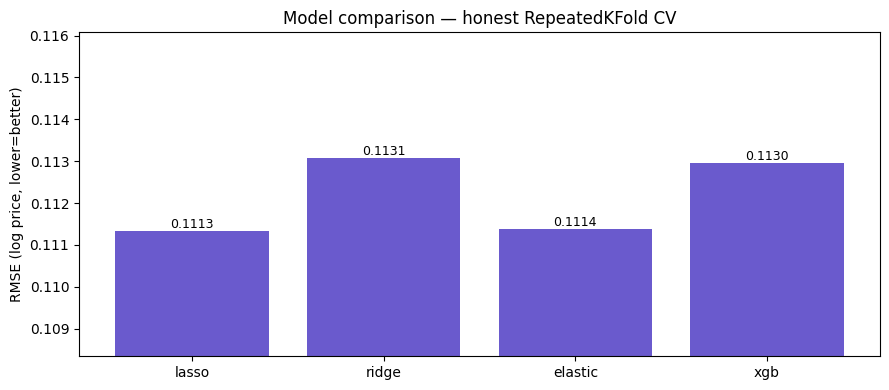

In [17]:
scores = {name: cv_honest(m) for name, m in best.items()}
plt.figure(figsize=(9, 4))
bars = plt.bar(scores.keys(), scores.values(), color='slateblue')
plt.ylabel('RMSE (log price, lower=better)')
plt.title('Model comparison — honest RepeatedKFold CV')
plt.ylim(min(scores.values())-0.003, max(scores.values())+0.003)
for b, v in zip(bars, scores.values()):
    plt.text(b.get_x()+b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

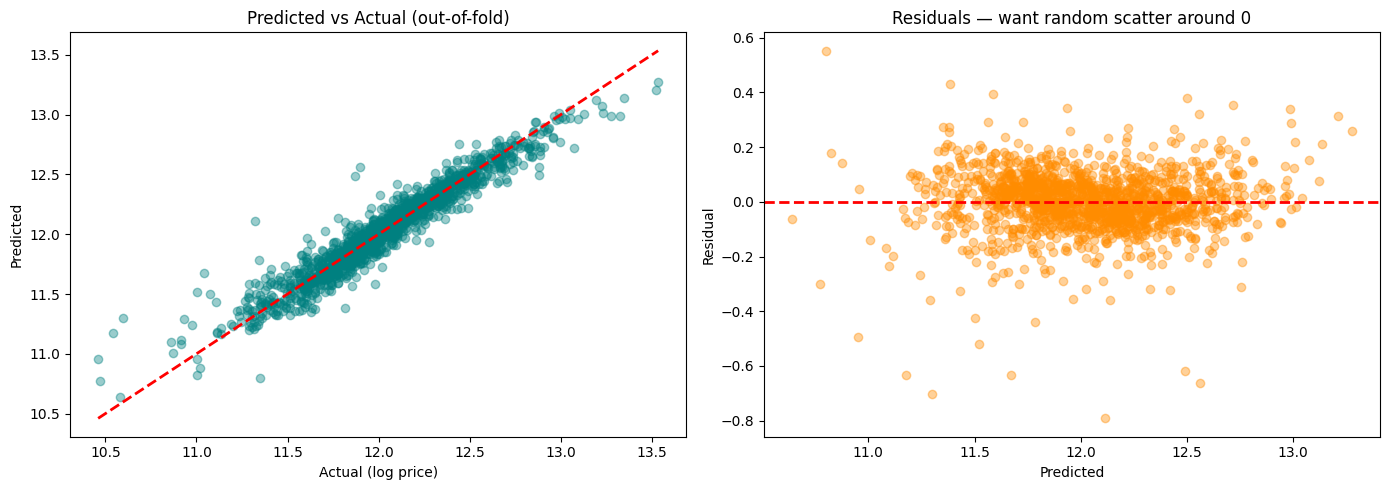

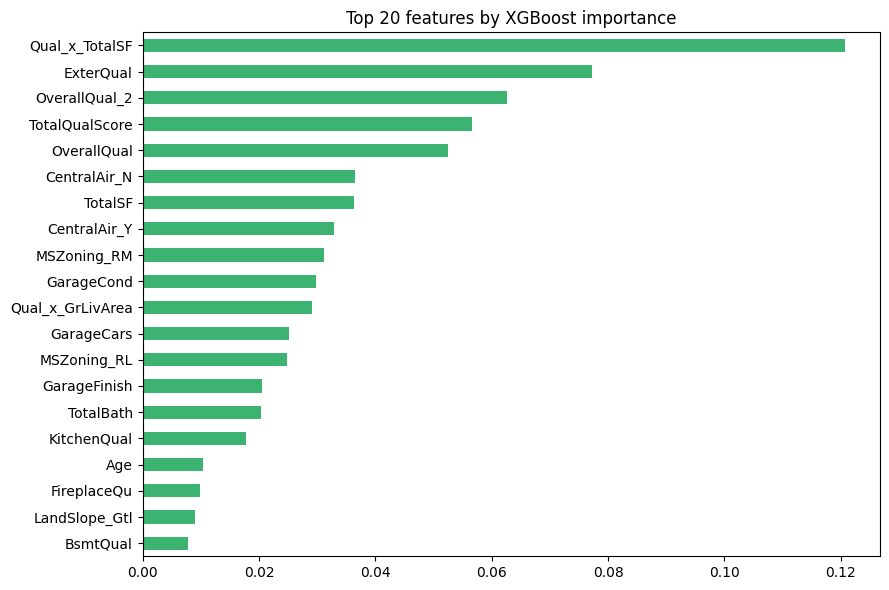

In [18]:
from sklearn.model_selection import cross_val_predict

# 1. Predicted vs actual (out-of-fold) — how well predictions track truth
oof_pred = cross_val_predict(best['lasso'], X, y, cv=kf)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(y, oof_pred, alpha=0.4, color='teal')
ax[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax[0].set_xlabel('Actual (log price)'); ax[0].set_ylabel('Predicted')
ax[0].set_title('Predicted vs Actual (out-of-fold)')

# 2. Residuals — should be random noise around 0
resid = y - oof_pred
ax[1].scatter(oof_pred, resid, alpha=0.4, color='darkorange')
ax[1].axhline(0, color='r', ls='--', lw=2)
ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('Residual')
ax[1].set_title('Residuals — want random scatter around 0')
plt.tight_layout(); plt.show()

# 3. XGBoost feature importance (top 20) — what drives predictions
best['xgb'].fit(X, y)
imp = pd.Series(best['xgb'].feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(9, 6))
imp[::-1].plot(kind='barh', color='mediumseagreen')
plt.title('Top 20 features by XGBoost importance'); plt.tight_layout(); plt.show()

In [19]:
def obj_lgb(t):
    p = {'n_estimators':     t.suggest_int('n_estimators',1000,4000,step=500),
         'learning_rate':    t.suggest_float('learning_rate',0.005,0.05,log=True),
         'num_leaves':       t.suggest_int('num_leaves',4,20),
         'max_depth':        t.suggest_int('max_depth',2,5),
         'min_child_samples':t.suggest_int('min_child_samples',5,40),
         'subsample':        t.suggest_float('subsample',0.5,0.9),
         'colsample_bytree': t.suggest_float('colsample_bytree',0.3,0.8),
         'reg_alpha':        t.suggest_float('reg_alpha',1e-3,10,log=True),
         'reg_lambda':       t.suggest_float('reg_lambda',1e-3,10,log=True),
         'random_state':42,'verbose':-1}
    return cv_kf(LGBMRegressor(**p))

sLg = optuna.create_study(direction='minimize')
sLg.optimize(obj_lgb, n_trials=40, show_progress_bar=True)
best['lgbm'] = LGBMRegressor(**sLg.best_params, random_state=42, verbose=-1)
print('LGBM', round(sLg.best_value,4), sLg.best_params)

  0%|          | 0/40 [00:00<?, ?it/s]

LGBM 0.1144 {'n_estimators': 2000, 'learning_rate': 0.032293487675764856, 'num_leaves': 10, 'max_depth': 3, 'min_child_samples': 5, 'subsample': 0.5007713175800498, 'colsample_bytree': 0.3887420618152089, 'reg_alpha': 0.054241185373249234, 'reg_lambda': 0.35977453521204256}


In [20]:
def obj_cat(t):
    p = {'iterations':      t.suggest_int('iterations',1000,4000,step=500),
         'learning_rate':   t.suggest_float('learning_rate',0.01,0.1,log=True),
         'depth':           t.suggest_int('depth',3,7),
         'l2_leaf_reg':     t.suggest_float('l2_leaf_reg',1,10,log=True),
         'subsample':       t.suggest_float('subsample',0.5,0.9),
         'random_strength': t.suggest_float('random_strength',0.1,10,log=True),
         'random_state':42,'verbose':0}
    return cv_kf(CatBoostRegressor(**p))

sC = optuna.create_study(direction='minimize')
sC.optimize(obj_cat, n_trials=40, show_progress_bar=True)
best['cat'] = CatBoostRegressor(**sC.best_params, random_state=42, verbose=0)
print('Cat', round(sC.best_value,4), sC.best_params)

  0%|          | 0/40 [00:00<?, ?it/s]

Cat 0.1103 {'iterations': 4000, 'learning_rate': 0.010218794372876937, 'depth': 4, 'l2_leaf_reg': 5.644845469690088, 'subsample': 0.7000674528063249, 'random_strength': 9.66671002732705}


cat      honest CV = 0.1105
lasso    honest CV = 0.1113
elastic  honest CV = 0.1114
xgb      honest CV = 0.1130
ridge    honest CV = 0.1131
lgbm     honest CV = 0.1148


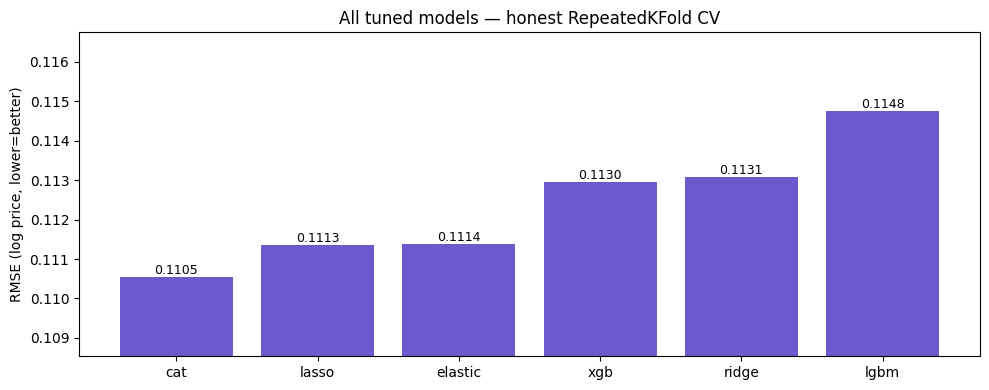

In [21]:
import matplotlib.pyplot as plt

scores = {name: cv_honest(m) for name, m in best.items()}
for name, s in sorted(scores.items(), key=lambda x: x[1]):
    print(f'{name:8} honest CV = {s:.4f}')

plt.figure(figsize=(10, 4))
order = sorted(scores, key=scores.get)
vals = [scores[k] for k in order]
bars = plt.bar(order, vals, color='slateblue')
plt.ylabel('RMSE (log price, lower=better)')
plt.title('All tuned models — honest RepeatedKFold CV')
plt.ylim(min(vals)-0.002, max(vals)+0.002)
for b, v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

In [22]:
from sklearn.model_selection import cross_val_predict

# Option A: stacking (meta-model learns the combination)
stack = StackingRegressor(
    estimators=list(best.items()),
    final_estimator=LassoCV(alphas=[1e-4,5e-4,1e-3,5e-3], max_iter=50000),
    cv=5, n_jobs=-1)
print('Stack honest CV =', round(cv_honest(stack), 4))

# Option B: simple average of all six (hard to overfit)
oof = {name: cross_val_predict(m, X, y, cv=kf) for name, m in best.items()}
blend_oof = np.mean(list(oof.values()), axis=0)
print('Equal blend CV  =', round(np.sqrt(np.mean((y - blend_oof)**2)), 4))

# Option C: blend of just the 3 best (cat, lasso, elastic) — sometimes cleaner
best3 = np.mean([oof['cat'], oof['lasso'], oof['elastic']], axis=0)
print('Best-3 blend CV =', round(np.sqrt(np.mean((y - best3)**2)), 4))

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/loc

Stack honest CV = 0.1075
Equal blend CV  = 0.1077
Best-3 blend CV = 0.1085


In [25]:
# Rebuild all six tuned models from the best params we already found
best = {
    'lasso':   make_pipeline(RobustScaler(), Lasso(alpha=0.000483, max_iter=50000)),
    'ridge':   make_pipeline(RobustScaler(), Ridge(alpha=8.204)),
    'elastic': make_pipeline(RobustScaler(), ElasticNet(alpha=0.000618, l1_ratio=0.807, max_iter=50000)),
    'xgb':     XGBRegressor(n_estimators=3500, learning_rate=0.02766, max_depth=3,
                            min_child_weight=3, subsample=0.6263, colsample_bytree=0.4480,
                            reg_alpha=0.1241, reg_lambda=0.5131, gamma=0.006437,
                            random_state=42, n_jobs=-1),
    'lgbm':    LGBMRegressor(n_estimators=2000, learning_rate=0.03229, num_leaves=10,
                             max_depth=3, min_child_samples=5, subsample=0.5008,
                             colsample_bytree=0.3887, reg_alpha=0.05424, reg_lambda=0.3598,
                             random_state=42, verbose=-1),
    'cat':     CatBoostRegressor(iterations=4000, learning_rate=0.010219, depth=4,
                                 l2_leaf_reg=5.6448, subsample=0.7001,
                                 random_strength=9.6667, random_state=42, verbose=0),
}
print("six tuned models rebuilt:", list(best.keys()))

six tuned models rebuilt: ['lasso', 'ridge', 'elastic', 'xgb', 'lgbm', 'cat']


In [26]:
stack = StackingRegressor(
    estimators=list(best.items()),
    final_estimator=LassoCV(alphas=[1e-4,5e-4,1e-3,5e-3], max_iter=50000),
    cv=5, n_jobs=-1)

stack.fit(X, y)                      # trains all six + meta-model, a few minutes
pred = np.expm1(stack.predict(X_test))
print('sample preds:', pred[:5])

submission = pd.DataFrame({'Id': test_ID, 'SalePrice': pred})
submission.to_csv(f'{path}/submission_tuned_stack.csv', index=False)
print(submission.shape)              # (1459, 2)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


sample preds: [121068.74305512 159491.04805453 180010.01155032 199671.63865784
 191343.85825107]
(1459, 2)
